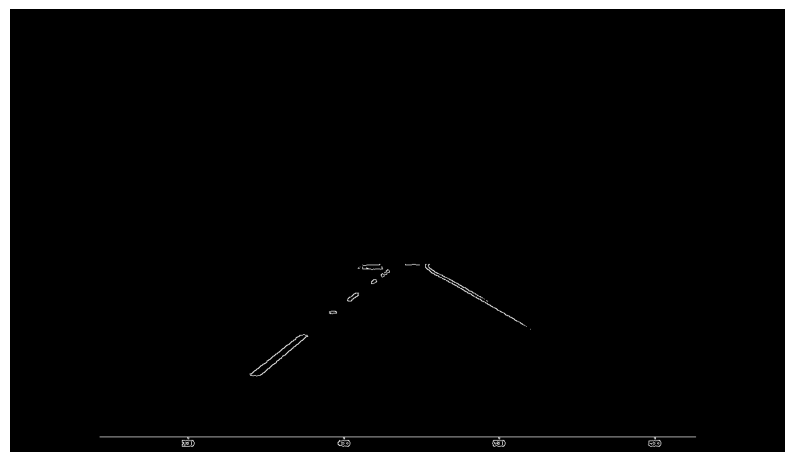

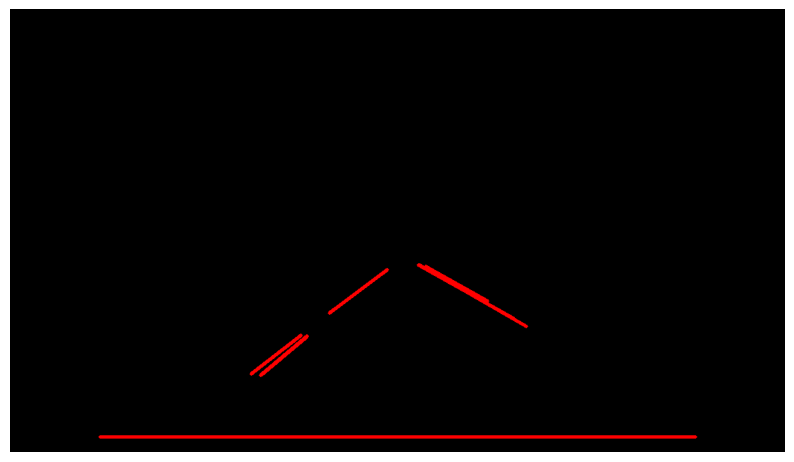

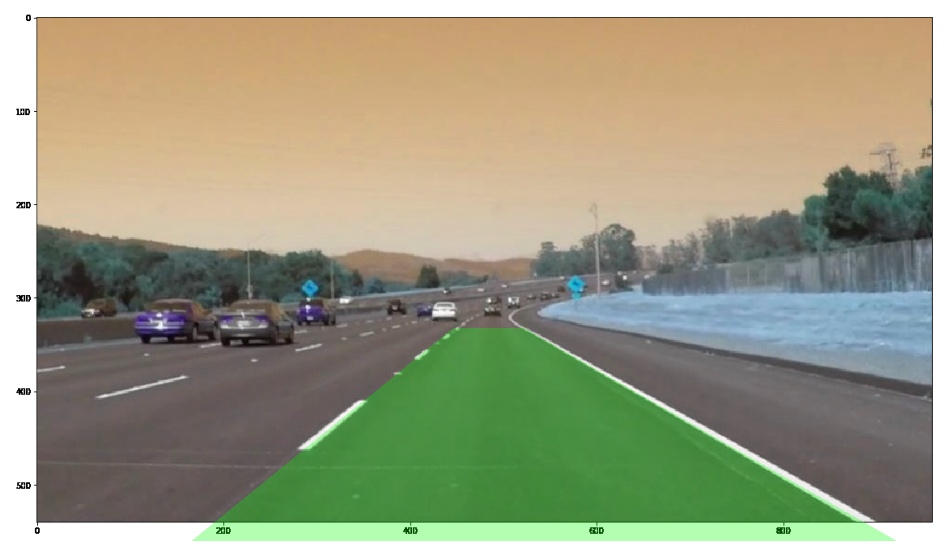

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. ACTUAL INITIALIZATION ---
# Replace 'your_road_image.jpg' with your actual image path!
img = cv2.imread('lanes.png') 

if img is not None:
    height, width = img.shape[:2]

    # Generate the edge-detected image (Canny)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, 50, 150)

    # Initialize the mask blank matrix
    mask = np.zeros_like(edges)

    # Define a triangular/polygonal region of interest for the lanes
    polygon = np.array([[
        (100, height), 
        (width // 2 - 50, height // 2 + 50), 
        (width // 2 + 50, height // 2 + 50), 
        (width - 100, height)
    ]], np.int32)


    # --- 2. REGION OF INTEREST & HOUGH LINES ---
    cv2.fillPoly(mask, polygon, 255)
    roi = cv2.bitwise_and(edges, mask)

    plt.figure(figsize=(10, 6))
    plt.imshow(roi, cmap="gray")
    plt.axis("off")
    plt.show()

    lines = cv2.HoughLinesP(roi, 1, np.pi / 180, threshold=50, minLineLength=50, maxLineGap=30)
    line_img = np.zeros_like(img)
    left_lines = []
    right_lines = []

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_img, (x1, y1), (x2, y2), (255, 0, 0), 3)
            if x2 == x1:
                continue
            slope = (y2 - y1) / (x2 - x1)
            if slope < -0.5:
                left_lines.append(line[0])
            elif slope > 0.5:
                right_lines.append(line[0])

        plt.figure(figsize=(10, 6))
        plt.imshow(line_img)
        plt.axis("off")
        plt.show()

        def average_line(lines):
            if len(lines) == 0:
                return None
            x_coords = []
            y_coords = []
            for x1, y1, x2, y2 in lines:
                x_coords.extend([x1, x2])
                y_coords.extend([y1, y2])
            return np.polyfit(x_coords, y_coords, 1)

        left_fit = average_line(left_lines)
        right_fit = average_line(right_lines)

        if left_fit is not None and right_fit is not None:
            y1 = height
            y2 = int(height * 0.6)
            
            left_x1 = int((y1 - left_fit[1]) / left_fit[0])
            left_x2 = int((y2 - left_fit[1]) / left_fit[0])
            right_x1 = int((y1 - right_fit[1]) / right_fit[0])
            right_x2 = int((y2 - right_fit[1]) / right_fit[0])

            overlay = img.copy()
            pts = np.array([[(left_x1, y1), (left_x2, y2), (right_x2, y2), (right_x1, y1)]], dtype=np.int32)
            cv2.fillPoly(overlay, pts, (0, 255, 0))
            result = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

            plt.figure(figsize=(12, 8))
            plt.imshow(result)
            plt.axis("off")
            plt.show()
        else:
            print("Could not reliably detect both left and right lane markers to create the overlay.")
    else:
        print("Error: No lines detected by HoughLinesP.")
else:
    print("Error: Image could not be loaded. Please check your image path configuration.")